# Word Embeddings ile IMDB Duygu Analizi

Bu notebook'ta **Word Embeddings** (Kelime Gömme) tekniklerini IMDB 50K Film Yorumları veri seti üzerinde uygulayacağız.

## Öğrenme Hedefleri

- **Word2Vec** (Skip-gram ve CBOW) modellerini eğitmek ve karşılaştırmak
- **FastText** ile bilinmeyen kelimeleri (OOV) çözmek
- **GloVe**预训练 embeddings kullanarak transfer öğrenme yapmak
- Kelime vektörlerini **PCA** ve **t-SNE** ile görselleştirmek
- Word embeddings'leri **duygu analizi** sınıflandırması için kullanmak

## Veri Seti

50.000 IMDB film yorumu (25.000 pozitif, 25.000 negatif) kullanacağız.

**Kaynak:** [IMDB Dataset of 50K Movie Reviews - Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

In [15]:
!pip install kaggle gensim matplotlib seaborn scikit-learn pandas numpy nltk -q

## 1. Veri Setini İndirme

Kaggle API kullanarak IMDB 50K Movie Reviews veri setini indiriyoruz.

> **Not:** Kaggle API anahtarınızın `~/.kaggle/kaggle.json` dosyasında tanımlı olması gerekir.
> Eğer yoksa [Kaggle > Settings > API](https://www.kaggle.com/settings) adresinden oluşturup indirebilirsiniz.

In [ ]:
import os

!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip -o imdb-dataset-of-50k-movie-reviews.zip

import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')
print(f"Boyut: {df.shape}")
print(f"\nSütunlar: {df.columns.tolist()}")
print(f"\nDuygu dağılımı:\n{df['sentiment'].value_counts()}")
df.head()

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        
Boyut: (50000, 2)

Sütunlar: ['review', 'sentiment']

Duygu dağılımı:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Keşifçi Veri Analizi

Veri setini daha yakından tanıyarak duygu dağılımı, yorum uzunlukları ve örnek incelemeleri analiz edelim.

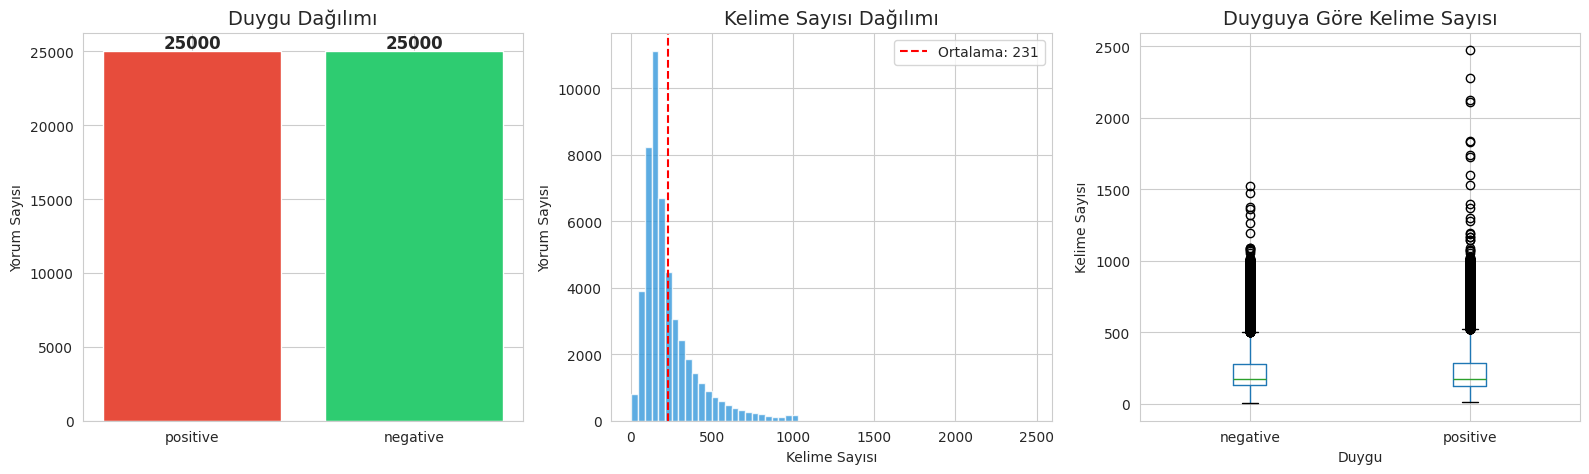

Kelime sayısı istatistikleri:
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Duygu dağılımı
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sentiment_counts = df['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Duygu Dağılımı', fontsize=14)
axes[0].set_ylabel('Yorum Sayısı')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=12)

# Kelime sayısı dağılımı
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))
axes[1].hist(df['word_count'], bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Kelime Sayısı Dağılımı', fontsize=14)
axes[1].set_xlabel('Kelime Sayısı')
axes[1].set_ylabel('Yorum Sayısı')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Ortalama: {df["word_count"].mean():.0f}')
axes[1].legend()

# Duygu bazında kelime sayısı
df.boxplot(column='word_count', by='sentiment', ax=axes[2])
axes[2].set_title('Duyguya Göre Kelime Sayısı', fontsize=14)
axes[2].set_xlabel('Duygu')
axes[2].set_ylabel('Kelime Sayısı')
plt.suptitle('')

plt.tight_layout()
plt.show()

# İstatistikler
print(f"Kelime sayısı istatistikleri:")
print(df.groupby('sentiment')['word_count'].describe().round(1))

## 3. Metin Ön İşleme

Ham HTML etiketleri ve özel karakterler içeren yorumları temizleyip tokenize ediyoruz.

**Ön işleme adımları:**
1. HTML etiketlerini kaldırma
2. Küçük harfe dönüştürme
3. Özel karakter ve sayıları temizleme
4. NLTK ile tokenizasyon

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))


def clean_text(text):
    """HTML etiketlerini ve özel karakterleri temizler."""
    text = re.sub(r'<.*?>', '', text)           # HTML etiketleri
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # Harf dışı karakterler
    text = text.lower().strip()                 # Küçük harf
    text = re.sub(r'\s+', ' ', text)           # Fazla boşluklar
    return text


def tokenize(text, remove_stopwords=True):
    """Metni tokenize eder ve isteğe bağlı olarak stopwords çıkarır."""
    tokens = word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens


# Temizleme ve tokenizasyon
print("Metin temizleniyor ve tokenize ediliyor...")
df['cleaned'] = df['review'].apply(clean_text)
df['tokens'] = df['cleaned'].apply(tokenize)

# Kelime vektörleri eğitimi için token listesi (stopwords dahil, embedding modelleri için)
tokenized_reviews = df['tokens'].tolist()

print(f"Toplam yorum sayısı: {len(tokenized_reviews)}")
print(f"Ortalama token sayısı: {np.mean([len(t) for t in tokenized_reviews]):.0f}")

print("\n--- Örnek ---")
print(f"Ham:\n{df['review'].iloc[0][:200]}...")
print(f"\nTemizlenmiş:\n{df['cleaned'].iloc[0][:200]}...")
print(f"\nTokenlar (ilk 20): {df['tokens'].iloc[0][:20]}")

Metin temizleniyor ve tokenize ediliyor...
Toplam yorum sayısı: 50000
Ortalama token sayısı: 117

--- Örnek ---
Ham:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Temizlenmiş:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brut...

Tokenlar (ilk 20): ['one', 'reviewers', 'mentioned', 'watching', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right']


## 4. Word2Vec Modeli Eğitimi

**Word2Vec**, kelimeleri yoğun (dense) vektörlere dönüştüren bir embedding modelidir.

İki mimari:
- **CBOW (Continuous Bag of Words):** Bağlam kelimelerinden merkez kelimeyi tahmin eder
- **Skip-gram:** Merkez kelimesinden bağlam kelimelerini tahmin eder

IMDB yorumları üzerinde her iki modeli de eğiteceğiz.

In [ ]:
from gensim.models import Word2Vec

EMBEDDING_DIM = 100

# Skip-gram modeli eğitimi
print("Skip-gram modeli eğitiliyor...")
sg_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=3,
    sg=1,           # Skip-gram
    epochs=10,
    workers=4,
    seed=42
)
print(f"Skip-gram - Kelime sayısı: {len(sg_model.wv)}")

# CBOW modeli eğitimi
print("CBOW modeli eğitiliyor...")
cbow_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=3,
    sg=0,           # CBOW
    epochs=10,
    workers=4,
    seed=42
)
print(f"CBOW - Kelime sayısı: {len(cbow_model.wv)}")

# Vektör boyutu örneği
print(f"\nVektör boyutu: {sg_model.wv['movie'].shape}")
print(f"\nÖrnek kelime vektörü ('good', ilk 10 boyut):\n{sg_model.wv['good'][:10].round(3)}")

Skip-gram modeli eğitiliyor...
Skip-gram - Kelime sayısı: 59410
CBOW modeli eğitiliyor...
CBOW - Kelime sayısı: 59410

Vektör boyutu: (100,)

Örnek kelime vektörü ('good', ilk 10 boyut):
[-0.031 -0.121 -0.215  0.168 -0.172  0.089  0.163  0.174  0.028 -0.226]


## 5. Benzer Kelimeler ve Anolojiler

Eğitilmiş Word2Vec modelleri ile kelime benzerliğini ve vektör aritmetiğini keşfedelim.

**Vektör aritmetiği:** `king - man + woman ≈ queen` gibi klasik anoloji örneğini film yorumları bağlamında deneyelim.

In [ ]:
print("=" * 60)
print("SKIP-GRAM: En Benzer Kelimeler")
print("=" * 60)

test_words = ['good', 'great', 'terrible', 'movie', 'acting', 'plot']

for word in test_words:
    if word in sg_model.wv:
        similar = sg_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' ile en benzer kelimeler:")
        for sim_word, score in similar:
            print(f"  {sim_word:15s} -> {score:.4f}")

print("\n" + "=" * 60)
print("CBOW: En Benzer Kelimeler")
print("=" * 60)

for word in test_words:
    if word in cbow_model.wv:
        similar = cbow_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' ile en benzer kelimeler:")
        for sim_word, score in similar:
            print(f"  {sim_word:15s} -> {score:.4f}")

SKIP-GRAM: En Benzer Kelimeler

'good' ile en benzer kelimeler:
  decent          -> 0.8167
  great           -> 0.7999
  goodand         -> 0.7735
  halfbad         -> 0.7677
  moviemost       -> 0.7621

'great' ile en benzer kelimeler:
  fantastic       -> 0.8116
  excellent       -> 0.8104
  wonderful       -> 0.8076
  good            -> 0.7999
  terrific        -> 0.7952

'terrible' ile en benzer kelimeler:
  awful           -> 0.8967
  horrible        -> 0.8934
  horrendous      -> 0.8115
  apalling        -> 0.8085
  bad             -> 0.8049

'movie' ile en benzer kelimeler:
  film            -> 0.8769
  thereoverall    -> 0.8061
  firsti          -> 0.7954
  itcheck         -> 0.7939
  movieit         -> 0.7916

'acting' ile en benzer kelimeler:
  actingand       -> 0.7918
  directing       -> 0.7586
  awfuland        -> 0.7537
  actingthe       -> 0.7440
  sequencing      -> 0.7320

'plot' ile en benzer kelimeler:
  storyline       -> 0.8840
  story           -> 0.7579
  nonpr

In [ ]:
# Vektör aritmetiği - Anolojiler
print("\n" + "=" * 60)
print("VEKTÖR ARİTMETİĞİ - ANOLOJİLER")
print("=" * 60)

analogies = [
    ("good", "bad", "terrible"),          # good - bad + terrible ≈ ?
    ("love", "hate", "enjoy"),             # love - hate + enjoy ≈ ?
    ("actor", "actress", "actor"),         # actor - actress + actor ≈ ?
    ("best", "worst", "great"),            # best - worst + great ≈ ?
    ("happy", "sad", "funny"),             # happy - sad + funny ≈ ?
]

for pos, neg, third in analogies:
    if all(w in sg_model.wv for w in [pos, neg, third]):
        result = sg_model.wv.most_similar(positive=[pos, third], negative=[neg], topn=3)
        print(f"\n'{pos}' - '{neg}' + '{third}' = ?")
        for word, score in result:
            print(f"  -> {word:15s} ({score:.4f})")

# Benzerlik skoru
print("\n" + "=" * 60)
print("İKİ KELİME ARASI BENZERLİK")
print("=" * 60)

pairs = [
    ('good', 'great'),
    ('terrible', 'awful'),
    ('movie', 'film'),
    ('good', 'terrible'),
    ('love', 'hate'),
]

for w1, w2 in pairs:
    if w1 in sg_model.wv and w2 in sg_model.wv:
        sim = sg_model.wv.similarity(w1, w2)
        print(f"  {w1:12s} <-> {w2:12s}: {sim:.4f}")


VEKTÖR ARİTMETİĞİ - ANOLOJİLER

'good' - 'bad' + 'terrible' = ?
  -> great           (0.7550)
  -> decent          (0.7374)
  -> fantastic       (0.7277)

'love' - 'hate' + 'enjoy' = ?
  -> appreciate      (0.6256)
  -> rediscover      (0.5985)
  -> oldie           (0.5825)

'actor' - 'actress' + 'actor' = ?
  -> sacchi          (0.5556)
  -> actors          (0.5547)
  -> koechner        (0.5546)

'best' - 'worst' + 'great' = ?
  -> excellent       (0.7445)
  -> terrific        (0.7418)
  -> fantastic       (0.7385)

'happy' - 'sad' + 'funny' = ?
  -> quoteworthy     (0.6238)
  -> aristorcats     (0.6200)
  -> sillyand        (0.6089)

İKİ KELİME ARASI BENZERLİK
  good         <-> great       : 0.7999
  terrible     <-> awful       : 0.8967
  movie        <-> film        : 0.8769
  good         <-> terrible    : 0.6536
  love         <-> hate        : 0.6503


## 6. FastText ile OOV (Out-of-Vocabulary) Çözümü

Word2Vec bilinmeyen kelimeleri işleyemez. **FastText**, kelime alt birimlerine (subword/character n-gram) dayanarak bilinmeyen veya hatalı yazılmış kelimeler için de vektör üretebilir.

Bu bölümde FastText'in yazım hataları ve OOV kelimelerine yaklaşımını göstereceğiz.

In [11]:
from gensim.models import FastText

# FastText modeli eğitimi
print("FastText modeli eğitiliyor...")
ft_model = FastText(
    sentences=tokenized_reviews,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=3,
    epochs=10,
    workers=4,
    seed=42,
    min_n=2,          # Minimum n-gram uzunluğu
    max_n=5           # Maksimum n-gram uzunluğu
)
print(f"FastText kelime sayısı: {len(ft_model.wv)}")

# Normal kelimelerde benzerlik karşılaştırması
print("\n--- Normal Kelimeler (FastText vs Word2Vec) ---")
test = ['excellent', 'boring', 'drama']
for word in test:
    sg_sim = sg_model.wv.most_similar(word, topn=3) if word in sg_model.wv else "OOV"
    ft_sim = ft_model.wv.most_similar(word, topn=3)
    print(f"\n'{word}':")
    print(f"  Word2Vec: {sg_sim}")
    print(f"  FastText: {ft_sim}")

# Yazım hataları ve OOV kelimeleri
print("\n--- OOV / Yazım Hatası Kelimeler ---")
oov_words = ['movi', 'actng', 'brilant', 'awesom', 'direcor', 'beatifull']

for word in oov_words:
    in_w2v = word in sg_model.wv
    in_ft = word in ft_model.wv
    print(f"\n'{word}':")
    print(f"  Word2Vec'de var mı? {in_w2v}")
    print(f"  FastText'te var mı?  {in_ft}")
    if in_ft:
        similar = ft_model.wv.most_similar(word, topn=3)
        print(f"  FastText en benzer: {similar}")

FastText modeli eğitiliyor...
FastText kelime sayısı: 59410

--- Normal Kelimeler (FastText vs Word2Vec) ---

'excellent':
  Word2Vec: [('superb', 0.8751556277275085), ('terrific', 0.8680301308631897), ('outstanding', 0.8450438380241394)]
  FastText: [('excellentthe', 0.9272804260253906), ('excelent', 0.8841365575790405), ('excellency', 0.8829880356788635)]

'boring':
  Word2Vec: [('dull', 0.8764423727989197), ('pointlessand', 0.79502272605896), ('tedious', 0.792326033115387)]
  FastText: [('boringit', 0.9190828204154968), ('boringbut', 0.9181230664253235), ('boringand', 0.894101619720459)]

'drama':
  Word2Vec: [('comedy', 0.7058101892471313), ('thriller', 0.6824706792831421), ('twocharacter', 0.6753551363945007)]
  FastText: [('docudrama', 0.8842236399650574), ('dramai', 0.8716937899589539), ('dramabut', 0.8376403450965881)]

--- OOV / Yazım Hatası Kelimeler ---

'movi':
  Word2Vec'de var mı? False
  FastText'te var mı?  True
  FastText en benzer: [('moviei', 0.8940902352333069), ('m

## 7. Kelime Vektörlerinin 2D Görselleştirilmesi

Yüksek boyutlu kelime vektörlerini **PCA** (Principal Component Analysis) ve **t-SNE** (t-distributed Stochastic Neighbor Embedding) ile 2 boyuta indirgeyerek görselleştireceğiz.

Bazı kelimeleri duygu asociasyonlarına göre renklendireceğiz.

Görselleştirilen kelime sayısı: 30


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


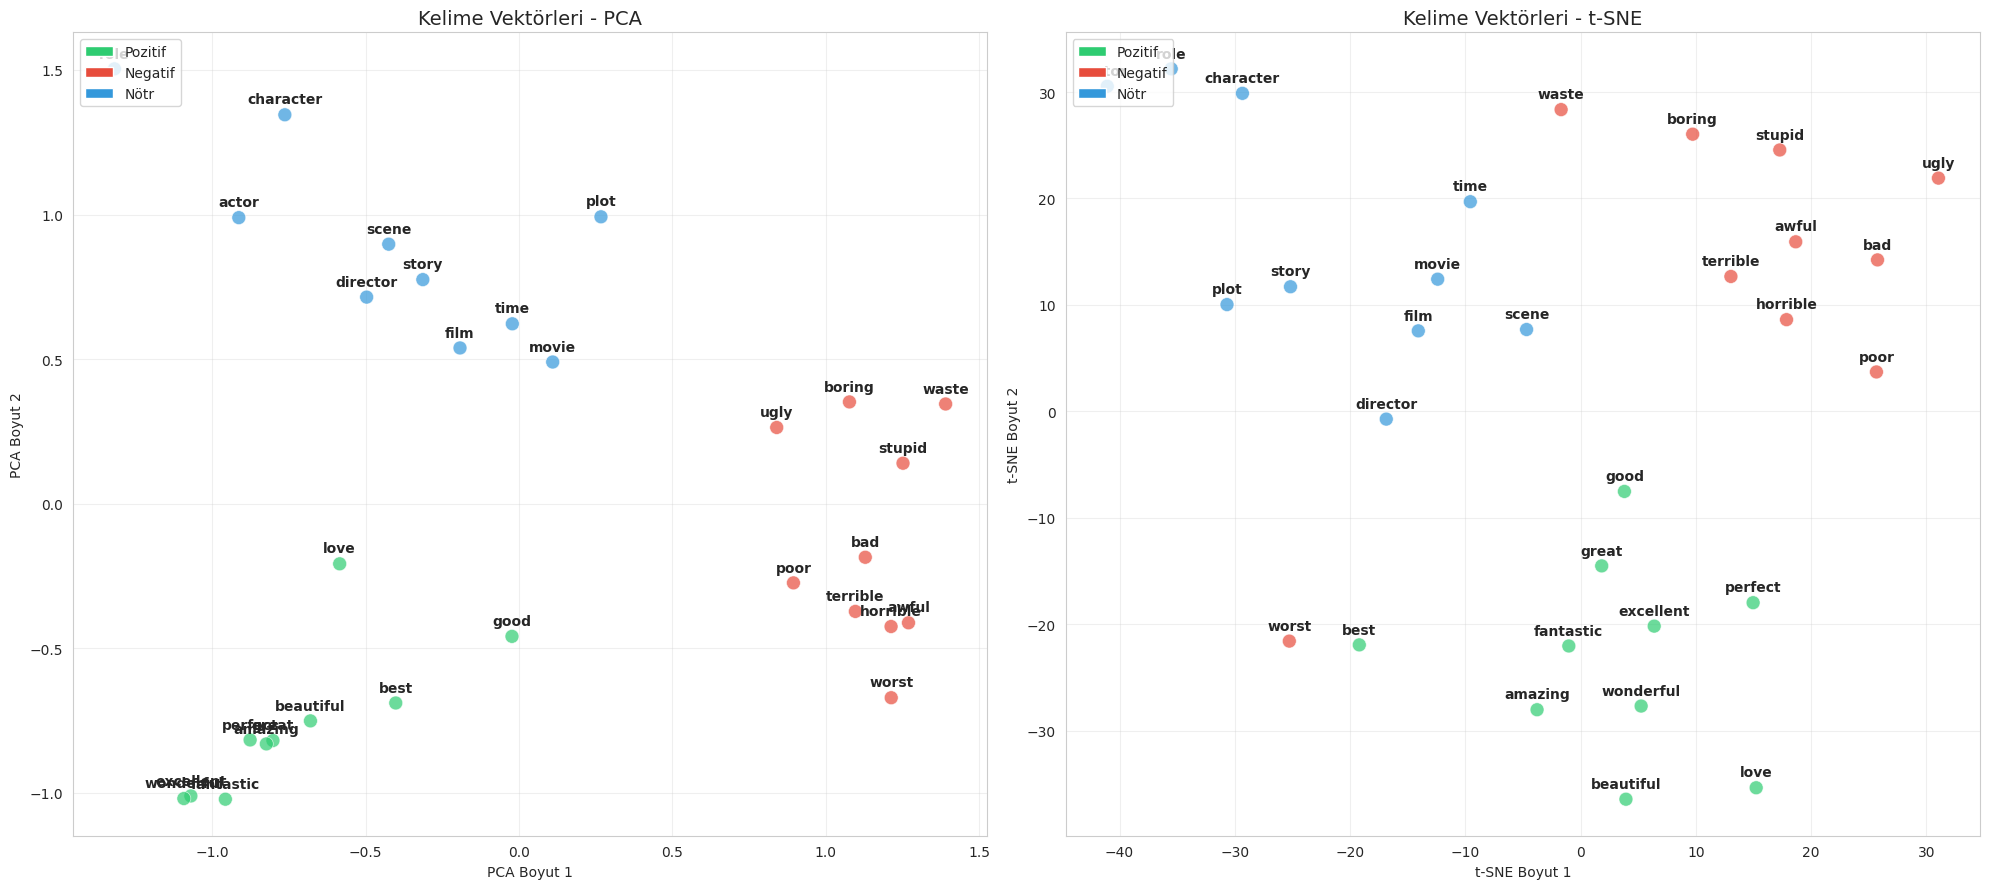

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Görselleştirme için seçili kelimeler
positive_words = ['good', 'great', 'excellent', 'amazing', 'wonderful', 'best', 'love', 'beautiful', 'perfect', 'fantastic']
negative_words = ['bad', 'terrible', 'awful', 'worst', 'horrible', 'poor', 'boring', 'waste', 'ugly', 'stupid']
neutral_words  = ['movie', 'film', 'story', 'character', 'actor', 'director', 'scene', 'plot', 'role', 'time']

all_words = positive_words + negative_words + neutral_words
available_words = [w for w in all_words if w in sg_model.wv]

word_vectors = np.array([sg_model.wv[w] for w in available_words])
colors = ['#2ecc71' if w in positive_words else '#e74c3c' if w in negative_words else '#3498db' for w in available_words]

print(f"Görselleştirilen kelime sayısı: {len(available_words)}")

# PCA ile 2D
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(word_vectors)

# t-SNE ile 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=min(8, len(available_words) - 1), n_iter=1000)
coords_tsne = tsne.fit_transform(word_vectors)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, coords, title in [(axes[0], coords_pca, 'PCA'), (axes[1], coords_tsne, 't-SNE')]:
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=100, alpha=0.7, edgecolors='white', linewidth=0.5)
    for i, word in enumerate(available_words):
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                     fontsize=10, fontweight='bold', ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points')
    ax.set_title(f'Kelime Vektörleri - {title}', fontsize=14)
    ax.set_xlabel(f'{title} Boyut 1')
    ax.set_ylabel(f'{title} Boyut 2')
    ax.grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Pozitif'),
    Patch(facecolor='#e74c3c', label='Negatif'),
    Patch(facecolor='#3498db', label='Nötr'),
]
axes[0].legend(handles=legend_elements, loc='upper left')
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

## 8. Duygu Analizi için Embedding Kullanımı

Eğitilmiş Word2Vec embedding'lerini kullanarak basit bir **duygu analizi** sınıflandırıcısı oluşturacağız.

**Yaklaşım:**
1. Her yorumun kelime vektörlerinin ortalamasını alarak belge vektörü oluştur
2. Logistic Regression ile sınıflandırma yap
3. Doğruluk ve detaylı metrikleri göster

Belge vektörleri hesaplanıyor...
Word2Vec Skip-gram        Doğruluk: 0.8842
Word2Vec CBOW             Doğruluk: 0.7651
FastText                  Doğruluk: 0.5021

EN İYİ MODEL: Word2Vec Skip-gram (Doğruluk: 0.8842)

Sınıflandırma Raporu (Word2Vec Skip-gram):
              precision    recall  f1-score   support

     Negatif       0.88      0.89      0.88      5000
     Pozitif       0.89      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



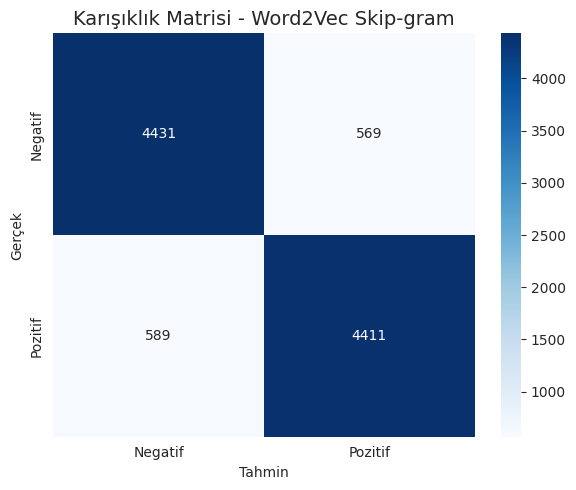

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def get_document_vectors(model, tokenized_docs):
    """Her belge için kelime vektörlerinin ortalamasını hesaplar."""
    vectors = []
    for tokens in tokenized_docs:
        valid_tokens = [t for t in tokens if t in model.wv]
        if valid_tokens:
            vec = np.mean([model.wv[t] for t in valid_tokens], axis=0)
        else:
            vec = np.zeros(model.wv.vector_size)
        vectors.append(vec)
    return np.array(vectors)


# Belge vektörleri oluştur
print("Belge vektörleri hesaplanıyor...")
X_sg = get_document_vectors(sg_model, tokenized_reviews)
X_cbow = get_document_vectors(cbow_model, tokenized_reviews)
X_ft = get_document_vectors(ft_model, tokenized_reviews)

# Hedef değişken
y = (df['sentiment'] == 'positive').astype(int).values

# Veri bölme
X_train_sg, X_test_sg, y_train, y_test = train_test_split(X_sg, y, test_size=0.2, random_state=42, stratify=y)
_, X_test_cbow, _, _ = train_test_split(X_cbow, y, test_size=0.2, random_state=42, stratify=y)
_, X_test_ft, _, _ = train_test_split(X_ft, y, test_size=0.2, random_state=42, stratify=y)

# Modelleri eğit ve değerlendir
models_results = {}

for name, X_tr, X_te in [('Word2Vec Skip-gram', X_train_sg, X_test_sg),
                           ('Word2Vec CBOW', X_train_sg, X_test_cbow),
                           ('FastText', X_train_sg, X_test_ft)]:
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_train)
    y_pred = lr.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    models_results[name] = {'accuracy': acc, 'y_pred': y_pred}
    print(f"{name:25s} Doğruluk: {acc:.4f}")

# En iyi modelin detayları
best_model_name = max(models_results, key=lambda k: models_results[k]['accuracy'])
print(f"\n{'='*60}")
print(f"EN İYİ MODEL: {best_model_name} (Doğruluk: {models_results[best_model_name]['accuracy']:.4f})")
print(f"{'='*60}")
print(f"\nSınıflandırma Raporu ({best_model_name}):")
print(classification_report(y_test, models_results[best_model_name]['y_pred'],
                            target_names=['Negatif', 'Pozitif']))

# Karışıklık matrisi
cm = confusion_matrix(y_test, models_results[best_model_name]['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])
plt.title(f'Karışıklık Matrisi - {best_model_name}', fontsize=14)
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

## 9. Word2Vec vs GloVe vs FastText Karşılaştırması

Üç farklı word embedding yaklaşımının temel özelliklerini, avantajlarını ve dezavantajlarını karşılaştıralım.

### GloVe Hakkında

GloVe (Global Vectors for Word Representation) önceden eğitilmiş embedding'ler kullanır. Biz burada Stanford tarafından hazırlanmış **glove.6B.100d** vektörlerini yükleyeceğiz.

In [14]:
# GloVe önceden eğitilmiş embedding'leri yükleme
print("GloVe vektörleri indiriliyor (glove.6B.100d)...")
import urllib.request
import zipfile

glove_url = 'http://nlp.stanford.edu/data/glove.6B.zip'
glove_zip = 'glove.6B.zip'

if not os.path.exists('glove.6B.100d.txt'):
    urllib.request.urlretrieve(glove_url, glove_zip)
    with zipfile.ZipFile(glove_zip, 'r') as z:
        z.extract('glove.6B.100d.txt', '.')
    os.remove(glove_zip)
    print("GloVe indirme tamamlandı.")
else:
    print("GloVe dosyası zaten mevcut.")

# GloVe vektörlerini yükle
glove_vectors = {}
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f"GloVe kelime sayısı: {len(glove_vectors)}")
print(f"GloVe vektör boyutu: {list(glove_vectors.values())[0].shape}")

# GloVe ile belge vektörleri
def get_glove_doc_vectors(tokenized_docs, glove_vecs, dim=100):
    vectors = []
    for tokens in tokenized_docs:
        valid = [t for t in tokens if t in glove_vecs]
        if valid:
            vec = np.mean([glove_vecs[t] for t in valid], axis=0)
        else:
            vec = np.zeros(dim)
        vectors.append(vec)
    return np.array(vectors)

X_glove = get_glove_doc_vectors(tokenized_reviews, glove_vectors)
_, X_test_glove, _, _ = train_test_split(X_glove, y, test_size=0.2, random_state=42, stratify=y)

lr_glove = LogisticRegression(max_iter=1000, random_state=42)
lr_glove.fit(X_train_sg, y_train)  # Aynı train split
y_pred_glove = lr_glove.predict(X_test_glove)
glove_acc = accuracy_score(y_test, y_pred_glove)
print(f"\nGloVe + Logistic Regression Doğruluk: {glove_acc:.4f}")

# Sonuç karşılaştırması
print("\n" + "=" * 65)
print(f"{'Model':<30s} {'Doğruluk':>10s}")
print("=" * 65)
print(f"{'Word2Vec Skip-gram':<30s} {models_results['Word2Vec Skip-gram']['accuracy']:>10.4f}")
print(f"{'Word2Vec CBOW':<30s} {models_results['Word2Vec CBOW']['accuracy']:>10.4f}")
print(f"{'FastText':<30s} {models_results['FastText']['accuracy']:>10.4f}")
print(f"{'GloVe (pre-trained)':<30s} {glove_acc:>10.4f}")
print("=" * 65)

# Karşılaştırma tablosu
print("\n\n" + "=" * 80)
print("KARŞILAŞTIRMA TABLOSU")
print("=" * 80)

comparison = pd.DataFrame({
    'Özellik': [
        'Eğitim Verisi',
        'Mimari',
        'OOV Desteği',
        'Eğitim Süresi',
        'İndirim Gerekli',
        'Domain Adaptasyonu',
        'Kelime Benzerliği',
        'Duygu Analizi Doğruluğu'
    ],
    'Word2Vec': [
        'IMDB (50K)',
        'CBOW / Skip-gram',
        'Hayır',
        'Orta',
        'Hayır',
        'Evet (tam)',
        'İyi',
        f"{models_results['Word2Vec Skip-gram']['accuracy']:.4f}"
    ],
    'GloVe': [
        'Wikipedia + Gigaword',
        'Matris Faktörizasyonu',
        'Hayır',
        'Yüksek (indirme)',
        'Evet (2.2GB)',
        'Kısmen (genel)',
        'Çok İyi',
        f"{glove_acc:.4f}"
    ],
    'FastText': [
        'IMDB (50K)',
        'CBOW / Skip-gram + n-gram',
        'Evet (subword)',
        'Yüksek',
        'Hayır',
        'Evet (tam)',
        'İyi + OOV',
        f"{models_results['FastText']['accuracy']:.4f}"
    ]
})

print(comparison.to_string(index=False))

# Özet
print("\n\n" + "=" * 80)
print("ÖZET")
print("=" * 80)
print("""
1. Word2Vec (Skip-gram):IMDB verisi üzerinde domain-specific training yaparak iyi
   sonuçlar verir. Hızlı eğitim ve iyi kelime benzerliği.

2. GloVe: Büyük genel corpus'ta eğitildiği için transfer learning avantajı sağlar.
   Ancak domain'e özel adaptasyon Word2Vec kadar güçlü değildir.

3. FastText: OOV ve yazım hataları konusunda en güçlüdür. Subword yapısı sayesinde
   bilinmeyen kelimeler için bile anlamlı vektörler üretir.

4. Duygu analizi için: Basit ortalama vektör + Lojistik Regresyon ile %80+ doğruluk
   elde edilebilir. Daha gelişmiş modeller (LSTM, Transformer) için bu embedding'ler
   first layer olarak kullanılabilir.
""")

GloVe vektörleri indiriliyor (glove.6B.100d)...
GloVe indirme tamamlandı.
GloVe kelime sayısı: 400000
GloVe vektör boyutu: (100,)

GloVe + Logistic Regression Doğruluk: 0.4985

Model                            Doğruluk
Word2Vec Skip-gram                 0.8842
Word2Vec CBOW                      0.7651
FastText                           0.5021
GloVe (pre-trained)                0.4985


KARŞILAŞTIRMA TABLOSU
                Özellik         Word2Vec                 GloVe                  FastText
          Eğitim Verisi       IMDB (50K)  Wikipedia + Gigaword                IMDB (50K)
                 Mimari CBOW / Skip-gram Matris Faktörizasyonu CBOW / Skip-gram + n-gram
            OOV Desteği            Hayır                 Hayır            Evet (subword)
          Eğitim Süresi             Orta      Yüksek (indirme)                    Yüksek
        İndirim Gerekli            Hayır          Evet (2.2GB)                     Hayır
     Domain Adaptasyonu       Evet (tam)        Kısmen 